In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alihamza01/heart-disease-uci/heart_disease_uci.csv


# load and inspect data

In [3]:
df = pd.read_csv("/kaggle/input/datasets/alihamza01/heart-disease-uci/heart_disease_uci.csv")

In [4]:
df.shape

(920, 16)

In [5]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


# Finding null values

In [8]:
df.isnull()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
916,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False
917,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
918,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False


In [9]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(1759)

In [11]:
for i in df.columns:
    print(i, df[i].dtypes, df[i].isnull().sum())

id int64 0
age int64 0
sex object 0
dataset object 0
cp object 0
trestbps float64 59
chol float64 30
fbs object 90
restecg object 2
thalch float64 55
exang object 55
oldpeak float64 62
slope object 309
ca float64 611
thal object 486
num int64 0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [13]:

import seaborn as sns
import matplotlib.pyplot as plt

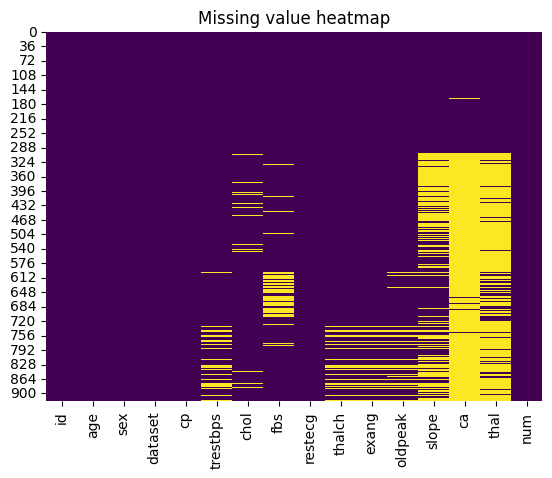

In [14]:
sns.heatmap(df.isnull(), cbar = False , cmap = "viridis")
plt.title("Missing value heatmap")
plt.show()

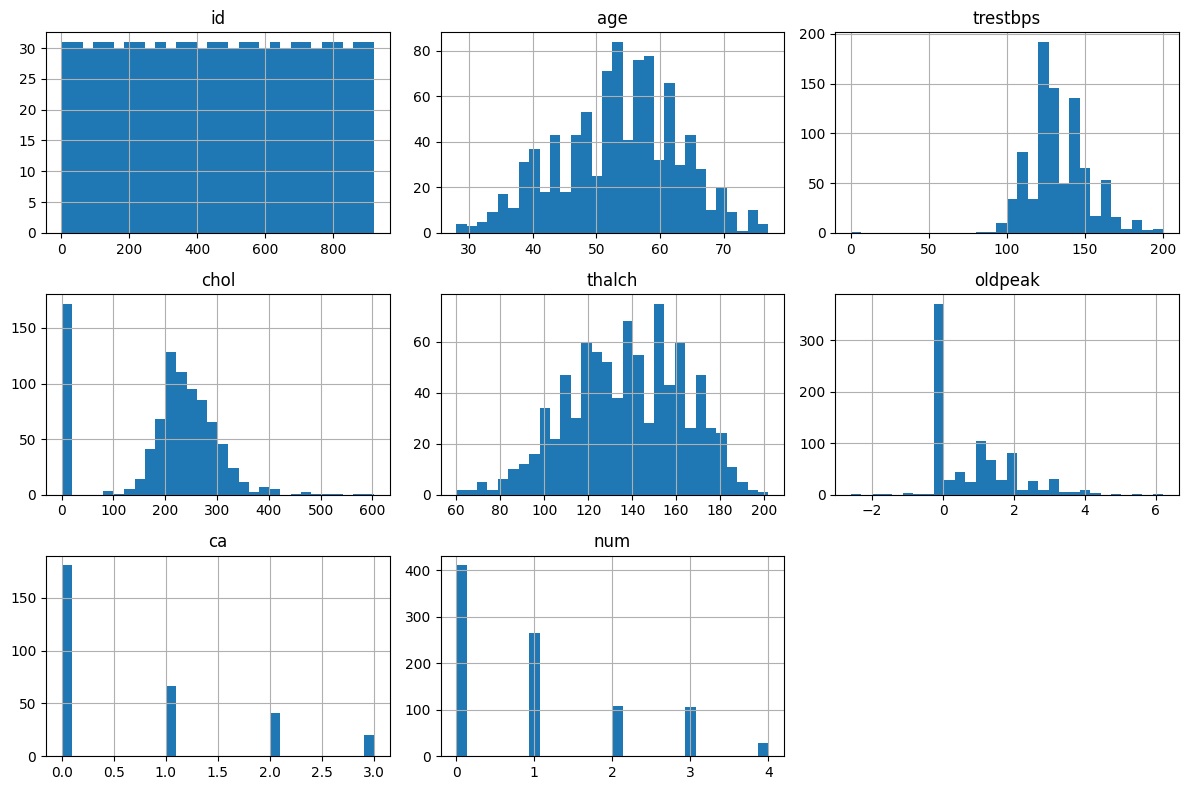

In [15]:
df.hist(figsize = (12,8), bins = 30)
plt.tight_layout()
plt.show()

In [16]:
(df.isnull().sum()/len(df)*100).round(2)

id           0.00
age          0.00
sex          0.00
dataset      0.00
cp           0.00
trestbps     6.41
chol         3.26
fbs          9.78
restecg      0.22
thalch       5.98
exang        5.98
oldpeak      6.74
slope       33.59
ca          66.41
thal        52.83
num          0.00
dtype: float64

In [17]:
for i in df:
    if(df[i].dtypes == 'int64'):
        print(i , df[i].dtypes , df[i].isna().sum())

id int64 0
age int64 0
num int64 0


In [18]:
for i in df:
    if(df[i].dtypes == 'float64'):
        print(i , df[i].dtypes , df[i].isna().sum())

trestbps float64 59
chol float64 30
thalch float64 55
oldpeak float64 62
ca float64 611


In [19]:
for i in df:
    if(df[i].dtypes == 'object'):
        print(i , df[i].dtypes , df[i].isna().sum())

sex object 0
dataset object 0
cp object 0
fbs object 90
restecg object 2
exang object 55
slope object 309
thal object 486


In [20]:
for i in df:
     if(df[i].dtypes == 'object' and df[i].isna().sum() != 0):
         print(i, df[i].dtypes, df[i].isna().sum())

fbs object 90
restecg object 2
exang object 55
slope object 309
thal object 486


In [21]:
for i in df:
     if(df[i].dtypes == 'int64' and df[i].isna().sum() != 0):
         print(i, df[i].dtypes, df[i].isna().sum())

In [22]:
for i in df:
     if(df[i].dtypes == 'float64' and df[i].isna().sum() != 0):
         print(i, df[i].dtypes, df[i].isna().sum())

trestbps float64 59
chol float64 30
thalch float64 55
oldpeak float64 62
ca float64 611


In [23]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   920 non-null    float64
 12  slope     611 non-null    object 
 13  ca        920 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [25]:
df.drop('thal', axis = 1, inplace = True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   920 non-null    float64
 12  slope     611 non-null    object 
 13  ca        920 non-null    float64
 14  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 107.9+ KB


# Encoding categorical

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [28]:
for i in df:
    if(df[i].dtypes == 'object'):
        df[i] = le.fit_transform(df[i])
        print(i,df[i].dtypes )

sex int64
dataset int64
cp int64
fbs int64
restecg int64
exang int64
slope int64


In [29]:
for i in df:
    print(df[i].value_counts().to_frame())

     count
id        
920      1
1        1
2        1
3        1
4        1
..     ...
13       1
12       1
11       1
10       1
9        1

[920 rows x 1 columns]
     count
age       
54      51
58      43
55      41
56      38
57      38
52      36
59      35
51      35
62      35
53      33
60      32
61      31
48      31
63      30
50      25
41      24
43      24
46      24
49      22
64      22
65      21
44      19
47      19
42      18
45      18
38      16
67      15
39      15
40      13
66      13
69      13
37      11
35      11
68      10
74       7
34       7
70       7
36       6
71       5
32       5
72       4
29       3
75       3
31       2
77       2
76       2
33       2
28       1
30       1
73       1
     count
sex       
1      726
0      194
         count
dataset       
0          304
1          293
3          200
2          123
    count
cp       
0     496
2     204
1     174
3      46
          count
trestbps       
130.0       174
120.0       131
140

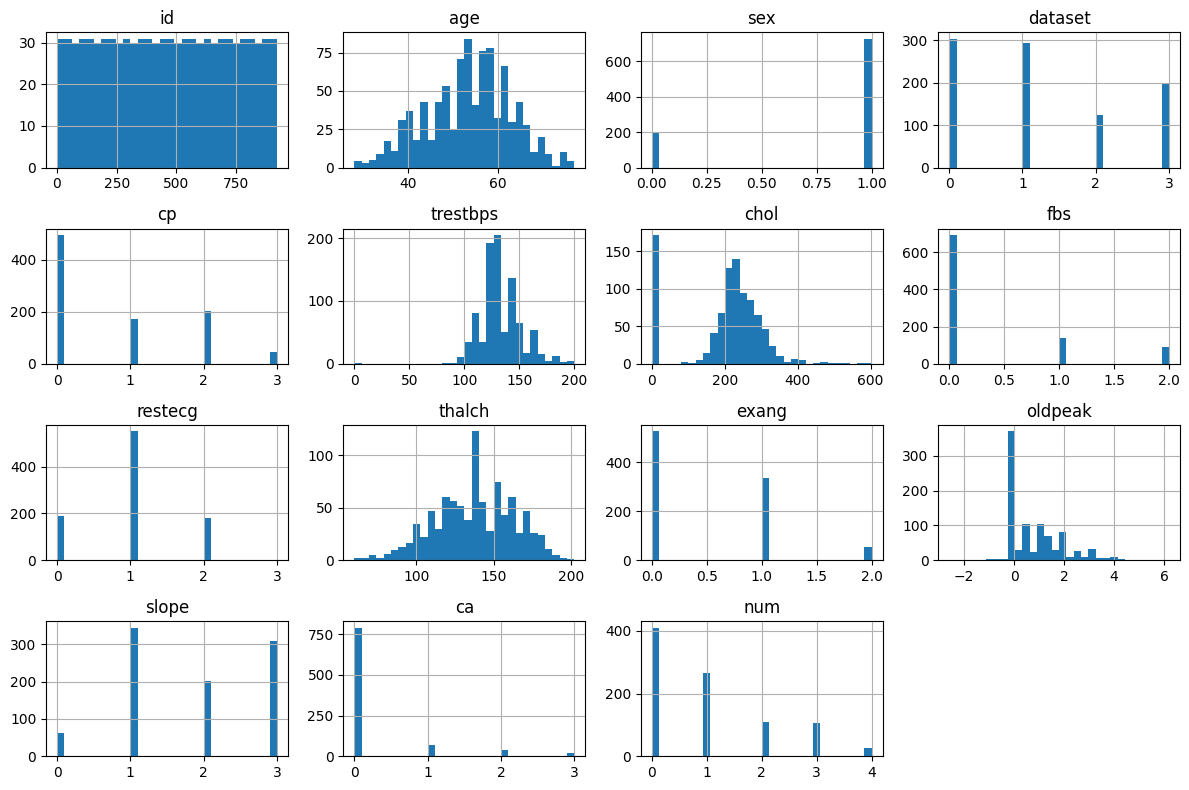

In [30]:
df.hist(figsize = (12,8), bins = 30)
plt.tight_layout()
plt.show()

In [31]:
correlation = df.corr()
correlation

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,num
id,1.000000,0.239301,0.280053,0.949062,-0.189430,0.039382,-0.370721,0.291005,0.477040,-0.428727,0.399679,0.014034,0.115371,-0.385881,0.273552
age,0.239301,1.000000,0.056889,0.235076,-0.076519,0.230784,-0.086010,0.125887,-0.013094,-0.349715,0.250938,0.233550,-0.222399,0.219413,0.339596
sex,0.280053,0.056889,1.000000,0.285734,-0.125933,-0.002145,-0.194029,0.106900,0.074900,-0.174590,0.207197,0.090794,-0.033180,-0.037847,0.259342
dataset,0.949062,0.235076,0.285734,1.000000,-0.150334,0.008343,-0.410777,0.293678,0.456794,-0.373492,0.399767,0.012767,0.131545,-0.371451,0.276203
cp,-0.189430,-0.076519,-0.125933,-0.150334,1.000000,-0.023980,0.065089,-0.078563,-0.064280,0.290613,-0.241050,-0.177489,0.183725,-0.046250,-0.314518
trestbps,0.039382,0.230784,-0.002145,0.008343,-0.023980,1.000000,0.089484,-0.012035,0.008492,-0.104747,0.100662,0.161217,-0.036134,0.039092,0.113178
chol,-0.370721,-0.086010,-0.194029,-0.410777,0.065089,0.089484,1.000000,-0.411801,-0.200712,0.226047,-0.030101,0.047454,0.090895,0.152514,-0.230539
fbs,0.291005,0.125887,0.106900,0.293678,-0.078563,-0.012035,-0.411801,1.000000,0.119873,-0.132731,0.004113,-0.000533,-0.063412,-0.032591,0.186664
restecg,0.477040,-0.013094,0.074900,0.456794,-0.064280,0.008492,-0.200712,0.119873,1.000000,-0.158089,0.141274,-0.051576,0.171056,-0.305697,0.034255
thalch,-0.428727,-0.349715,-0.174590,-0.373492,0.290613,-0.104747,0.226047,-0.132731,-0.158089,1.000000,-0.262704,-0.149401,0.169757,0.038207,-0.349173


<Axes: >

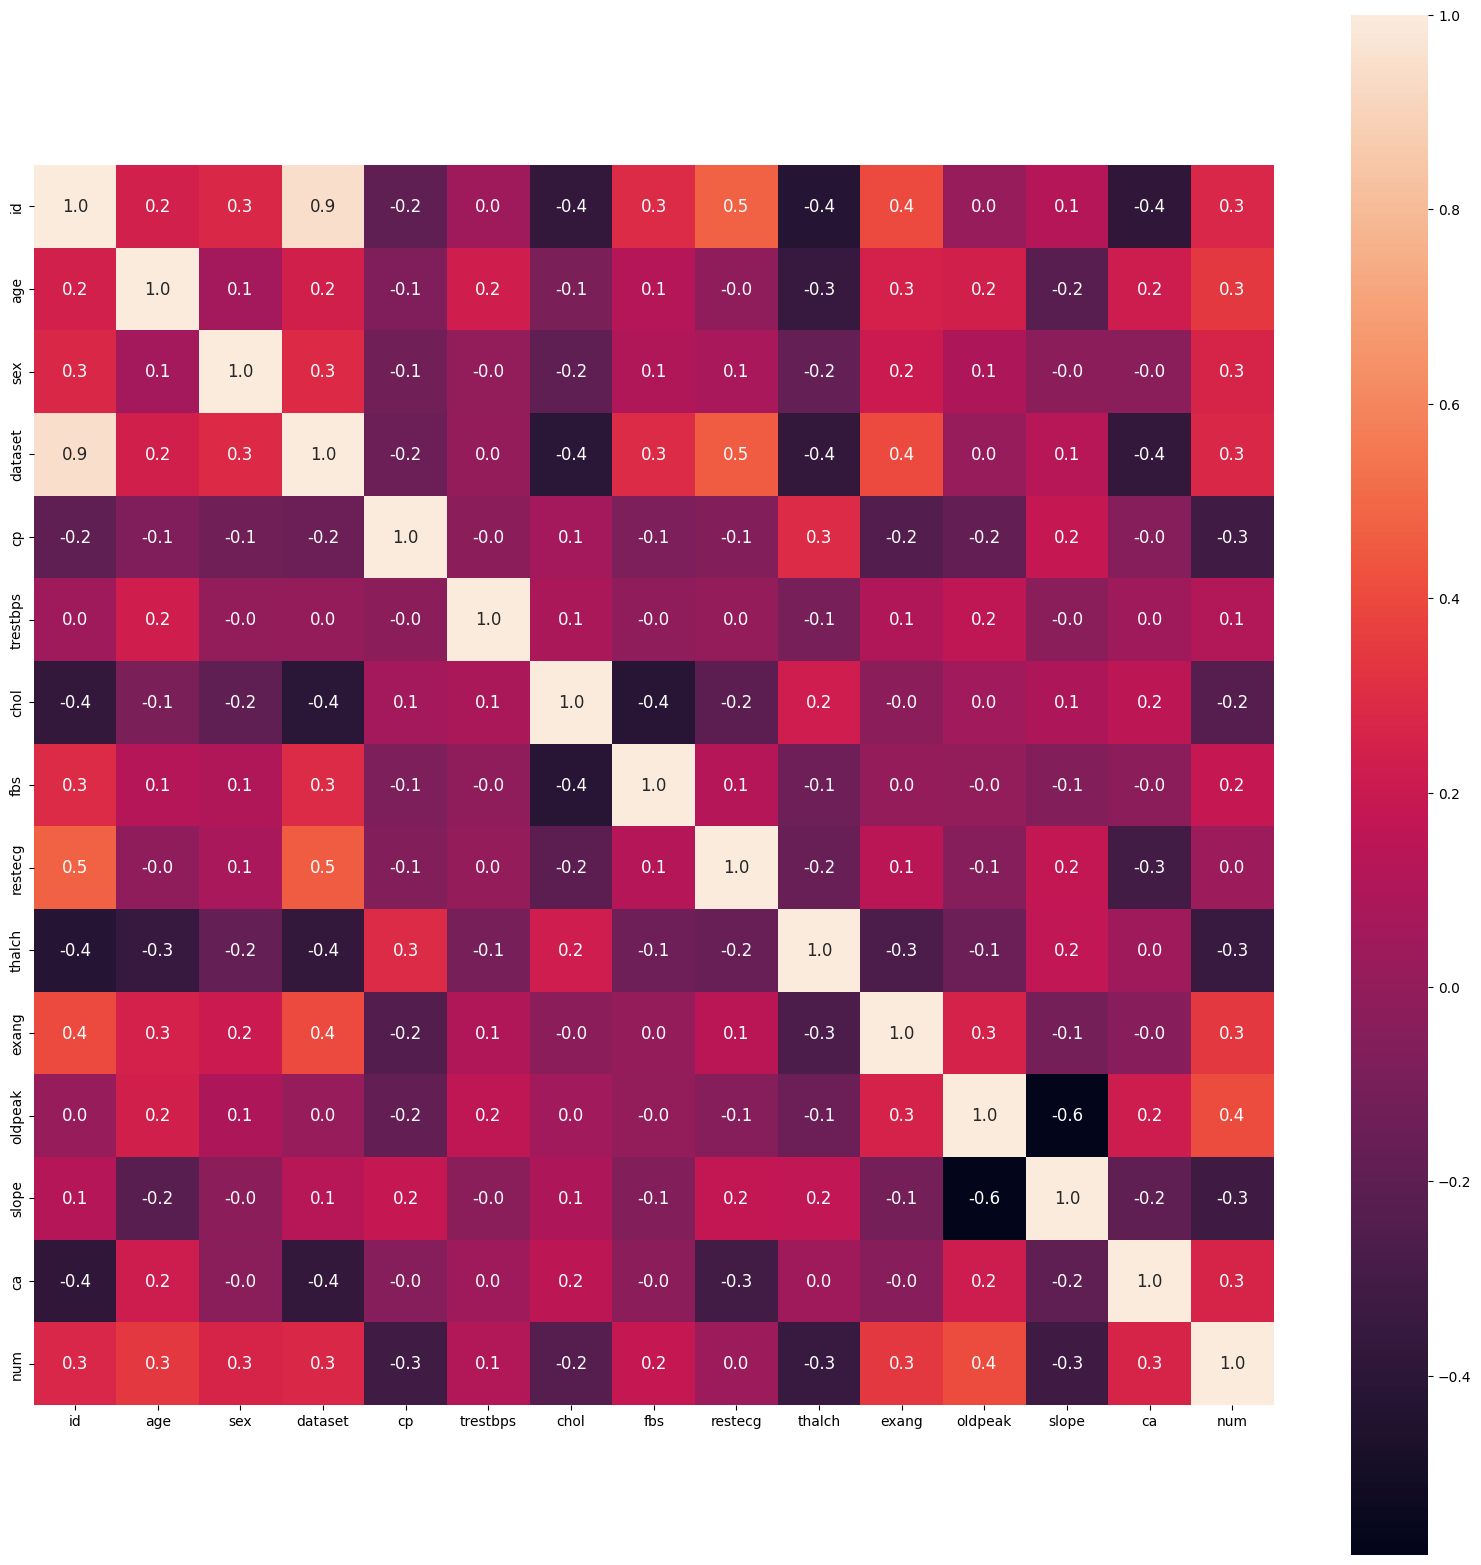

In [32]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation , square = True, fmt = '.1f',annot = True, annot_kws = {'size':12})

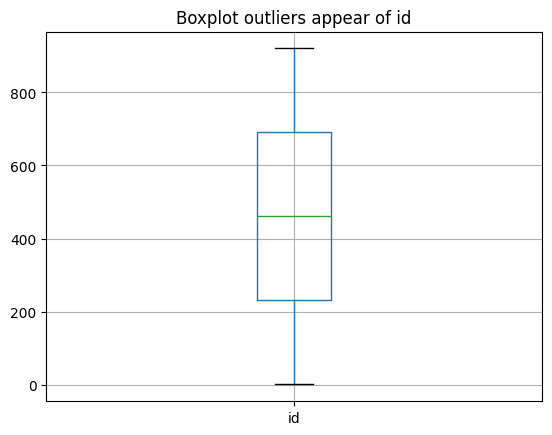

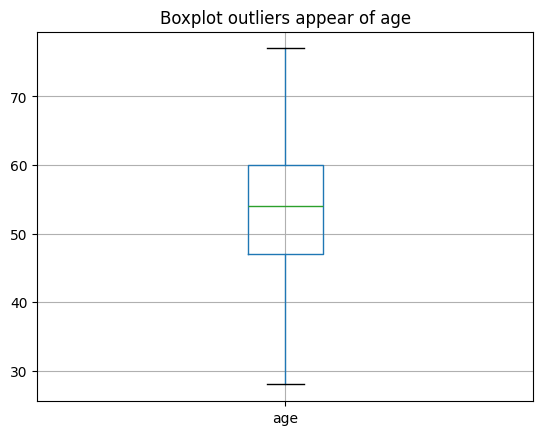

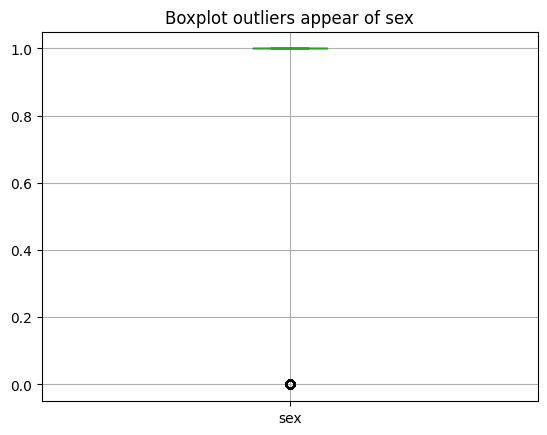

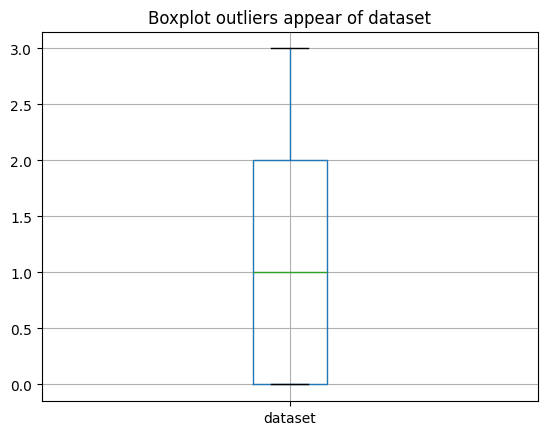

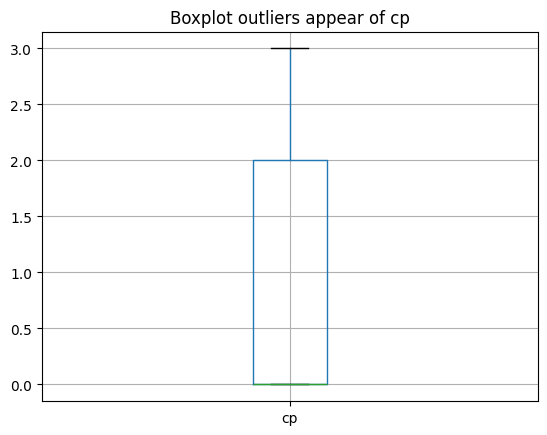

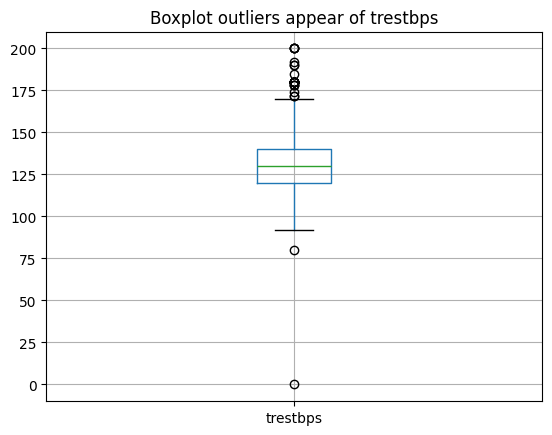

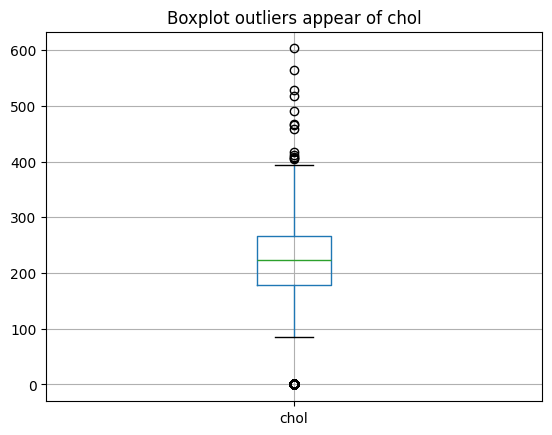

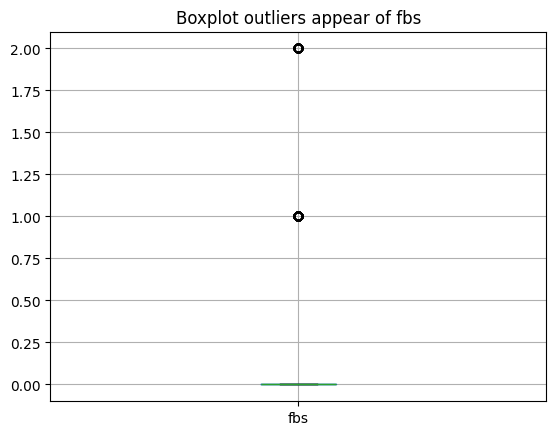

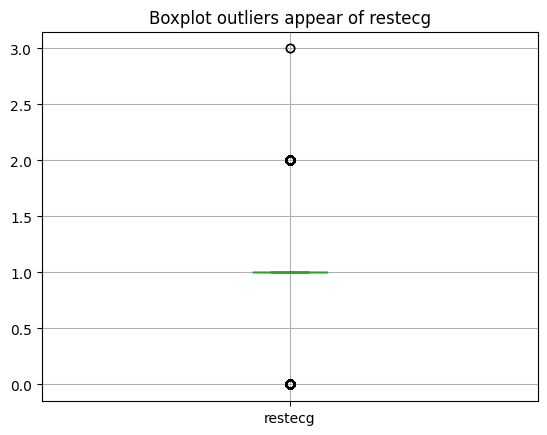

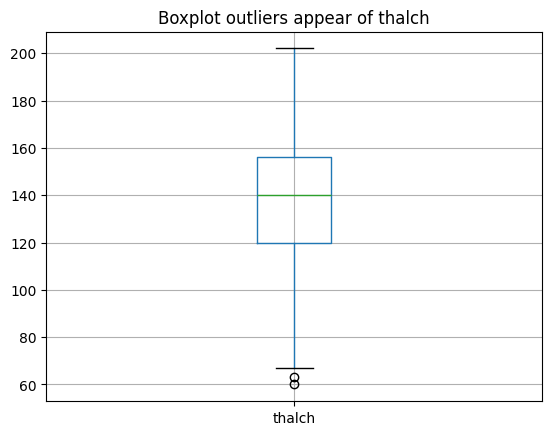

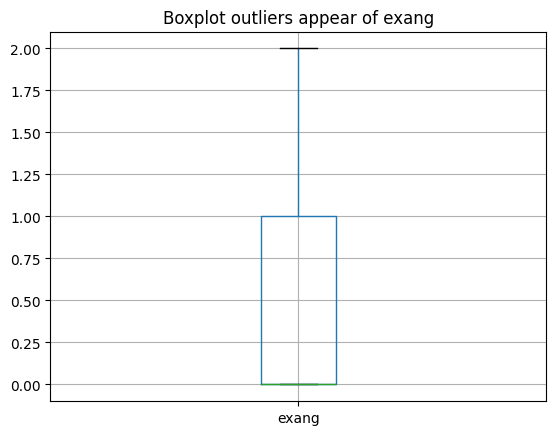

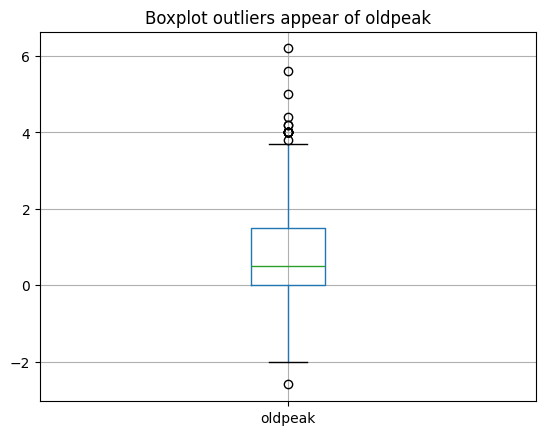

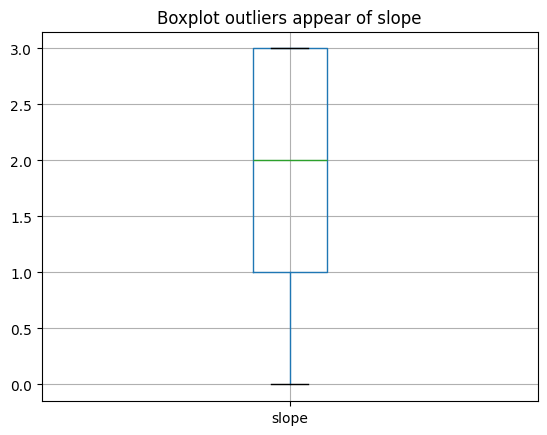

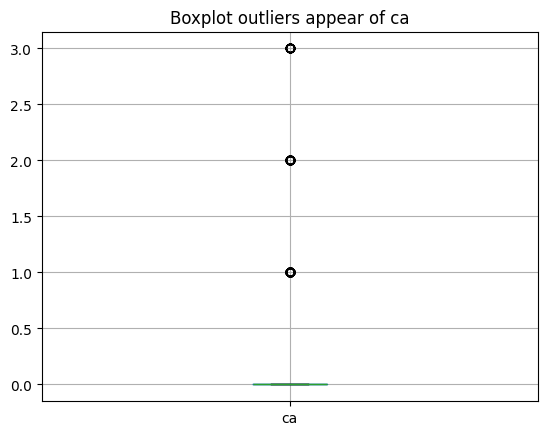

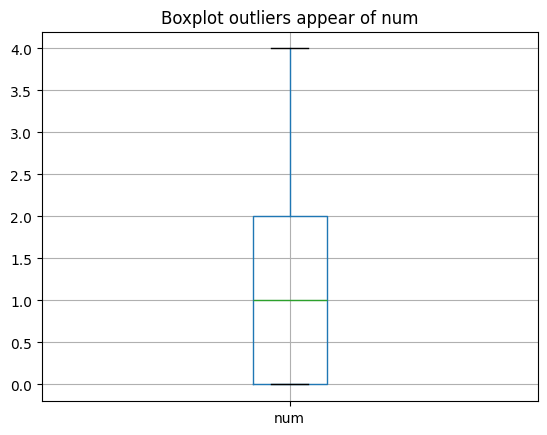

In [33]:
for i in df.columns:
    pd.DataFrame(df[i]).boxplot()
    plt.title("Boxplot outliers appear of "+ i)
    plt.show()

In [34]:
max(df['oldpeak'])

6.2

In [35]:
df['oldpeak'].mean()

np.float64(0.8532608695652174)

In [36]:
df.drop(df[df['oldpeak'] > 6].index, inplace = True)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        919 non-null    int64  
 1   age       919 non-null    int64  
 2   sex       919 non-null    int64  
 3   dataset   919 non-null    int64  
 4   cp        919 non-null    int64  
 5   trestbps  919 non-null    float64
 6   chol      919 non-null    float64
 7   fbs       919 non-null    int64  
 8   restecg   919 non-null    int64  
 9   thalch    919 non-null    float64
 10  exang     919 non-null    int64  
 11  oldpeak   919 non-null    float64
 12  slope     919 non-null    int64  
 13  ca        919 non-null    float64
 14  num       919 non-null    int64  
dtypes: float64(5), int64(10)
memory usage: 114.9 KB


In [38]:
min(df['trestbps'])

0.0

In [39]:
df.drop('id', axis = 1, inplace = True)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       919 non-null    int64  
 1   sex       919 non-null    int64  
 2   dataset   919 non-null    int64  
 3   cp        919 non-null    int64  
 4   trestbps  919 non-null    float64
 5   chol      919 non-null    float64
 6   fbs       919 non-null    int64  
 7   restecg   919 non-null    int64  
 8   thalch    919 non-null    float64
 9   exang     919 non-null    int64  
 10  oldpeak   919 non-null    float64
 11  slope     919 non-null    int64  
 12  ca        919 non-null    float64
 13  num       919 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 107.7 KB


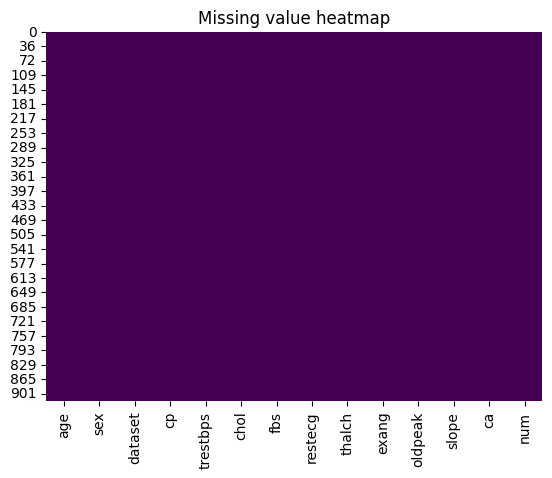

In [41]:
sns.heatmap(df.isnull(), cbar = False , cmap = "viridis")
plt.title("Missing value heatmap")
plt.show()

# Train/Split

In [42]:
from sklearn.model_selection import train_test_split


In [43]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

In [44]:
X = df.drop("num", axis=1)
y = df["num"]
len(X)

919

In [45]:
len(y)

919

In [46]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,stratify=y)

In [47]:
print('Size of Train X', len(X_train))
print('Size of Train y',len(y_train))
print('Size of Test X',len(X_test))
print('Size of Test y',len(y_test))

Size of Train X 735
Size of Train y 735
Size of Test X 184
Size of Test y 184


**Logistic Regression**

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
LModel = LogisticRegression(solver='liblinear',random_state=32)

In [50]:
LModel.fit(X_train,y_train)
LogisticRegression(random_state=32, solver='liblinear')

LogisticRegression(random_state=32, solver='liblinear')

**Training**

In [51]:
training_data_prediction_lr = LModel.predict(X_train)
print(training_data_prediction_lr)

[1 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0 1 1
 1 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 0 0 0 0 0 1
 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 1
 0 1 1 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 0 1 0 1 0 1 1 0 1 1 1 1
 1 0 0 0 1 1 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1
 1 0 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 0
 0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0 1 0 0
 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 0 0 0 1 1 1 0 0 0 1 0 0 1
 0 1 1 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1
 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1
 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 1 0 1 1 0
 0 1 0 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 1 0 0
 0 0 0 1 0 1 0 1 0 0 1 0 

In [52]:
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score

In [53]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_lr))
print("F1_score : ",f1_score(y_train,training_data_prediction_lr,average='weighted'))

Accuracy :  0.8272108843537415
F1_score :  0.8272354554031571


In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_train, training_data_prediction_lr))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       329
           1       0.84      0.84      0.84       406

    accuracy                           0.83       735
   macro avg       0.83      0.83      0.83       735
weighted avg       0.83      0.83      0.83       735



In [55]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

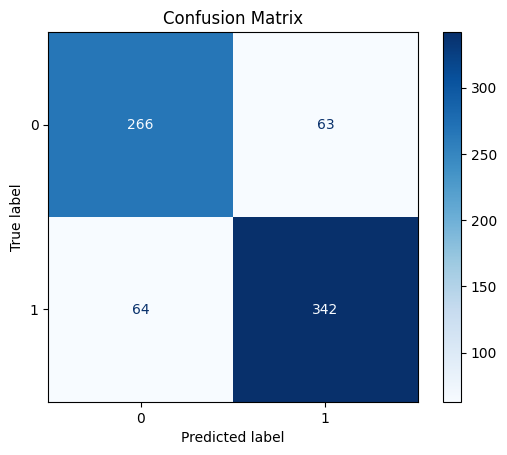

In [56]:
cm = confusion_matrix(y_train, training_data_prediction_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

**Testing**

In [57]:
testing_data_prediction_lr = LModel.predict(X_test)
y_prob = LModel.predict_proba(X_test)[:,1]
print(testing_data_prediction_lr)

[0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 1
 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1
 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 1 0 1 1
 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0
 1 0 1 0 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 0 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1]


In [58]:
print("Accuracy : ",accuracy_score(y_test,testing_data_prediction_lr))
print("F1_score : ",f1_score(y_test,testing_data_prediction_lr,average='weighted'))
print("ROC_AUC :",roc_auc_score(y_test, y_prob))

Accuracy :  0.8097826086956522
F1_score :  0.8098905092908091
ROC_AUC : 0.882831181252989


**Decission Tree**

In [59]:
from sklearn.tree import DecisionTreeClassifier

In [60]:
Dtree = DecisionTreeClassifier(random_state=30)

In [61]:
Dtree.fit(X_train, y_train)
DecisionTreeClassifier(random_state=30)

DecisionTreeClassifier(random_state=30)

**Training**

In [62]:
training_data_prediction_dt =Dtree.predict(X_train)
print(training_data_prediction_dt)

[1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1
 1 0 1 0 1 1 0 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 1
 0 1 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 1 1 1 1 1 1 0
 0 0 0 0 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 0
 0 1 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 1 0 0 0 0
 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 0
 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0
 0 1 1 1 0 1 1 0 1 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 0 1 0 0 0
 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1
 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 0 1 1
 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 1 0 0
 0 1 1 1 0 1 1 1 0 0 1 0 

In [63]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_dt))
print("F1_score : ",f1_score(y_train,training_data_prediction_dt,average='weighted'))

Accuracy :  1.0
F1_score :  1.0


**Testing**

In [64]:
testing_data_prediction_dt = Dtree.predict(X_test)
y_prob = Dtree.predict_proba(X_test)[:,1]
print(testing_data_prediction_dt)

[0 1 1 1 0 1 1 0 0 1 1 0 0 0 1 1 0 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 1 0 1 1 1
 0 0 1 0 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0 0 0 1 0 0 0 1 0 1
 0 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1
 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0
 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 1 1]


In [65]:
print("Accuracy : ",accuracy_score(y_test,testing_data_prediction_dt))
print("F1_score : ",f1_score(y_test,testing_data_prediction_dt,average='weighted'))
print("ROC_AUC :",roc_auc_score(y_test, y_prob))

Accuracy :  0.7663043478260869
F1_score :  0.7664369114144227
ROC_AUC : 0.7641080822572931


**Random Forest Classifier**

In [66]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
rf_model =RandomForestClassifier(n_estimators=10, random_state=30)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=30)

In [68]:
training_data_prediction_rf =rf_model.predict(X_train)
print(training_data_prediction_rf)

[1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1
 1 0 1 0 1 1 0 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 1 0 0 0 1
 0 1 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 1 1 1 0 1 1 0
 0 0 0 0 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 0
 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 1 1 1 1 0 1 0 0 0 0
 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 0
 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0
 0 1 1 1 0 1 1 0 1 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 0 1 0 0 0
 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1
 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 0 1 1
 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 1 1 1 0 0
 0 1 1 1 0 1 1 1 0 0 1 0 

In [69]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_rf))
print("F1_score : ",f1_score(y_train,training_data_prediction_rf,average='weighted'))

Accuracy :  0.9836734693877551
F1_score :  0.9836864651089291


**Testing**

In [70]:
testing_data_prediction_rf = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]
print(testing_data_prediction_rf)

[0 1 0 1 1 1 0 0 0 1 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 1 1
 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1
 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 0 1 0 1 1
 0 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0
 1 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 1 0 1 0 0 1 0 1 1 1 1]


In [71]:
print("Accuracy : ",accuracy_score(y_test,testing_data_prediction_rf))
print("F1_score : ",f1_score(y_test,testing_data_prediction_rf,average='weighted'))
print("ROC_AUC :",roc_auc_score(y_test, y_prob))

Accuracy :  0.8206521739130435
F1_score :  0.8209246659180017
ROC_AUC : 0.8892276422764228


In [72]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

AttributeError: 'SVC' object has no attribute 'SVC'

In [74]:
# SVM.fit(X_train, y_train)
# SVC(kernel='linear',probability=True)

In [78]:
training_data_prediction_svm =svm_model.predict(X_train)
print(training_data_prediction_svm)

[1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0
 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 1 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0 1 1
 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 0 0 0 1 1
 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 1 1 1 0 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0
 1 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 1 1 0
 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 0
 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 0 0
 0 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 1 0 0 1 0
 1 0 1 1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 1
 0 1 1 0 0 1 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 1 1 1 1 1 0 0 1 1 0 1 0 1 0 0 1
 0 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 0 1 1 0 0
 1 0 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 0 1 1
 0 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 1 1 0 0
 0 1 0 1 0 0 1 1 0 0 1 0 

In [79]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_svm))
print("F1_score : ",f1_score(y_train,training_data_prediction_svm,average='weighted'))

Accuracy :  0.7129251700680272
F1_score :  0.7136859243157408


In [81]:
testing_data_prediction_svm = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:,1]
print(testing_data_prediction_svm)

[1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0 0 1
 1 0 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1
 0 1 1 1 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 1 1
 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 1 1 1 1
 0 0 1 0 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0]


In [82]:
 print("Accuracy : ",accuracy_score(y_test,testing_data_prediction_svm))
print("F1_score : ",f1_score(y_test,testing_data_prediction_svm,average='weighted'))
print("ROC_AUC :",roc_auc_score(y_test, y_prob))

Accuracy :  0.7119565217391305
F1_score :  0.7121199140689396
ROC_AUC : 0.7772596843615495


In [83]:
models = {
    'Logistic Regression': LModel,
    'Decision Tree': Dtree,
    'Random Forest': rf_model,
    'SVM': svm_model
}

In [84]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results).round(3)
comparison_df

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.810,0.828,0.883
1,Decision Tree,0.766,0.788,0.764
2,Random Forest,0.821,0.836,0.889
3,SVM,0.712,0.739,0.777


In [85]:
comparison_df.sort_values(by='ROC-AUC', ascending=False)

,Model,Accuracy,F1 Score,ROC-AUC
2,Random Forest,0.821,0.836,0.889
0,Logistic Regression,0.810,0.828,0.883
3,SVM,0.712,0.739,0.777
1,Decision Tree,0.766,0.788,0.764


# Curve line 
**One chart for all models**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(6,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC={auc_score:.3f})'
    )

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()

plt.show()